## Power Outages

**Name(s)**: Vivian Zhu

**Website Link**: https://v1zhu.github.io/Power_Outage/

In [141]:
import pandas as pd
import numpy as np
from pathlib import Path

import plotly.express as px
pd.options.plotting.backend = 'plotly'

from dsc80_utils import * # Feel free to uncomment and use this.

## Step 1: Introduction

In [142]:
#!pip install openpyxl

In [278]:
# Load the data
outage = pd.read_excel('outage.xlsx',
                       header = 5, 
                       skiprows = [6],
                       usecols="B:BE")
outage

,OBS,YEAR,MONTH,U.S._STATE,...,AREAPCT_UC,PCT_LAND,PCT_WATER_TOT,PCT_WATER_INLAND
0,1,2011,7.0,Minnesota,...,0.60,91.59,8.41,5.48
1,2,2014,5.0,Minnesota,...,0.60,91.59,8.41,5.48
2,3,2010,10.0,Minnesota,...,0.60,91.59,8.41,5.48
...,...,...,...,...,...,...,...,...,...
1531,1532,2009,8.0,South Dakota,...,0.15,98.31,1.69,1.69
1532,1533,2009,8.0,South Dakota,...,0.15,98.31,1.69,1.69
1533,1534,2000,NaN,Alaska,...,0.02,85.76,14.24,2.90


In [281]:
# how many rows and columns are in the dataframe
outage.shape

(1534, 56)

## Brainstorm questions  
1. Where and when do power outages occurr?
2. What affects the duration of power outages?

In [211]:
# what are all the columns of outage
outage.columns

Index(['OBS', 'YEAR', 'MONTH', 'U.S._STATE', 'POSTAL.CODE', 'NERC.REGION',
       'CLIMATE.REGION', 'ANOMALY.LEVEL', 'CLIMATE.CATEGORY',
       'OUTAGE.START.DATE', 'OUTAGE.START.TIME', 'OUTAGE.RESTORATION.DATE',
       'OUTAGE.RESTORATION.TIME', 'CAUSE.CATEGORY', 'CAUSE.CATEGORY.DETAIL',
       'HURRICANE.NAMES', 'OUTAGE.DURATION', 'DEMAND.LOSS.MW',
       'CUSTOMERS.AFFECTED', 'RES.PRICE', 'COM.PRICE', 'IND.PRICE',
       'TOTAL.PRICE', 'RES.SALES', 'COM.SALES', 'IND.SALES', 'TOTAL.SALES',
       'RES.PERCEN', 'COM.PERCEN', 'IND.PERCEN', 'RES.CUSTOMERS',
       'COM.CUSTOMERS', 'IND.CUSTOMERS', 'TOTAL.CUSTOMERS', 'RES.CUST.PCT',
       'COM.CUST.PCT', 'IND.CUST.PCT', 'PC.REALGSP.STATE', 'PC.REALGSP.USA',
       'PC.REALGSP.REL', 'PC.REALGSP.CHANGE', 'UTIL.REALGSP', 'TOTAL.REALGSP',
       'UTIL.CONTRI', 'PI.UTIL.OFUSA', 'POPULATION', 'POPPCT_URBAN',
       'POPPCT_UC', 'POPDEN_URBAN', 'POPDEN_UC', 'POPDEN_RURAL',
       'AREAPCT_URBAN', 'AREAPCT_UC', 'PCT_LAND', 'PCT_WATER_TOT',
    

Filter the outage dataframe to the columns that I want

## Analysis
Provide an introduction to your dataset, and clearly state the one question your project is centered around. Why should readers of your website care about the dataset and your question specifically? Report the number of rows in the dataset, the names of the columns that are relevant to your question, and descriptions of those relevant columns.

This Dataset contains information about power outages. Contaiing things like what time did the outage happen, where it happened, information about the population nearby, what was the cause of the outage etc.
The dataset has 1534 rows, and 56 columns.
The columns that are relevant to this analysis are ...

Question: How do different factors influence the duration of the power outage and how can we use these factors to predict the outage duration.

## Step 2: Data Cleaning and Exploratory Data Analysis

## Data Cleaning

In [285]:
# filter outage to relevant columns
outage = outage[['YEAR','MONTH', 'U.S._STATE', 'POSTAL.CODE', 'NERC.REGION', 'CLIMATE.REGION', 'CLIMATE.CATEGORY', 'ANOMALY.LEVEL',
                 'OUTAGE.START.DATE', 'OUTAGE.START.TIME', 'OUTAGE.RESTORATION.DATE', 'OUTAGE.RESTORATION.TIME', 'CAUSE.CATEGORY', 'HURRICANE.NAMES', 'OUTAGE.DURATION','CUSTOMERS.AFFECTED','TOTAL.PRICE']]
outage

,YEAR,MONTH,U.S._STATE,POSTAL.CODE,...,HURRICANE.NAMES,OUTAGE.DURATION,CUSTOMERS.AFFECTED,TOTAL.PRICE
0,2011,7.0,Minnesota,MN,...,NaN,3060.0,70000.0,9.28
1,2014,5.0,Minnesota,MN,...,NaN,1.0,NaN,9.28
2,2010,10.0,Minnesota,MN,...,NaN,3000.0,70000.0,8.15
...,...,...,...,...,...,...,...,...,...
1531,2009,8.0,South Dakota,SD,...,NaN,59.0,NaN,7.67
1532,2009,8.0,South Dakota,SD,...,NaN,181.0,NaN,7.67
1533,2000,NaN,Alaska,AK,...,NaN,NaN,14273.0,NaN


In [286]:
#added two columns outage.start and outage.restoration
outage['OUTAGE.START'] = (
    pd.to_datetime(outage['OUTAGE.START.DATE']) +
    pd.to_timedelta(outage['OUTAGE.START.TIME'].astype(str))
)

outage['OUTAGE.RESTORATION'] = (
    pd.to_datetime(outage['OUTAGE.RESTORATION.DATE']) +
    pd.to_timedelta(outage['OUTAGE.RESTORATION.TIME'].astype(str))
)
outage

,YEAR,MONTH,U.S._STATE,POSTAL.CODE,...,CUSTOMERS.AFFECTED,TOTAL.PRICE,OUTAGE.START,OUTAGE.RESTORATION
0,2011,7.0,Minnesota,MN,...,70000.0,9.28,2011-07-01 17:00:00,2011-07-03 20:00:00
1,2014,5.0,Minnesota,MN,...,NaN,9.28,2014-05-11 18:38:00,2014-05-11 18:39:00
2,2010,10.0,Minnesota,MN,...,70000.0,8.15,2010-10-26 20:00:00,2010-10-28 22:00:00
...,...,...,...,...,...,...,...,...,...
1531,2009,8.0,South Dakota,SD,...,NaN,7.67,2009-08-29 22:54:00,2009-08-29 23:53:00
1532,2009,8.0,South Dakota,SD,...,NaN,7.67,2009-08-29 11:00:00,2009-08-29 14:01:00
1533,2000,NaN,Alaska,AK,...,14273.0,NaN,NaT,NaT


In [287]:
#make sure datatype for OUTAGE.RESTORATION is correct
outage['OUTAGE.RESTORATION'].dtypes

dtype('<M8[ns]')

In [288]:
#see how many columns have null values/
outage.isna().sum().sort_values(ascending=False)

HURRICANE.NAMES            1462
CUSTOMERS.AFFECTED          443
OUTAGE.RESTORATION.DATE      58
                           ... 
POSTAL.CODE                   0
CLIMATE.REGION                0
CAUSE.CATEGORY                0
Length: 19, dtype: int64

In [289]:
# create new column that tells whether or not there is a hurricance
outage['IS.HURRICANE'] = outage['HURRICANE.NAMES'].notna()

In [290]:
# find number of null values for the time columns
outage[['OUTAGE.RESTORATION', 'OUTAGE.DURATION', 'OUTAGE.START']].sort_values('OUTAGE.RESTORATION').isna().sum()

OUTAGE.RESTORATION    58
OUTAGE.DURATION       58
OUTAGE.START           9
dtype: int64

In [291]:
# drop columns that are null for time, no good way to predict what it was suppose to be
# drop the hurricane names column, replaced by IS.HURRICANE column
outage = outage[outage['OUTAGE.RESTORATION'].notna() & outage['OUTAGE.START'].notna() & outage['OUTAGE.DURATION'].notna()]
outage = outage.drop(columns=['HURRICANE.NAMES'])

In [292]:
# all null values for the CLIMATE.REGION column is due to the state being Hawaii
outage[outage['U.S._STATE']== 'Hawaii']['CLIMATE.REGION']

1515    Hawaii
1516    Hawaii
1517    Hawaii
1518    Hawaii
1519    Hawaii
Name: CLIMATE.REGION, dtype: object

Hawaii is not included in the 9 Climate Regions. 

In [293]:
#find for what rows is TOTAL.PRICE null, it is null for all rows that year is equal to 2016 and month is July
outage[outage['TOTAL.PRICE'].isna()]

,YEAR,MONTH,U.S._STATE,POSTAL.CODE,...,TOTAL.PRICE,OUTAGE.START,OUTAGE.RESTORATION,IS.HURRICANE


In [294]:
outage[(outage['YEAR'] == 2016) & (outage['MONTH'] == 7)]

,YEAR,MONTH,U.S._STATE,POSTAL.CODE,...,TOTAL.PRICE,OUTAGE.START,OUTAGE.RESTORATION,IS.HURRICANE
103,2016,7.0,Michigan,MI,...,17.40,2016-07-08 19:00:00,2016-07-09 00:00:00,False
171,2016,7.0,Texas,TX,...,17.40,2016-07-05 02:45:00,2016-07-06 03:00:00,False
218,2016,7.0,Texas,TX,...,7.52,2016-07-09 17:45:00,2016-07-11 14:00:00,False
...,...,...,...,...,...,...,...,...,...
1419,2016,7.0,Oklahoma,OK,...,17.40,2016-07-14 14:44:00,2016-07-15 04:00:00,False
1520,2016,7.0,Idaho,ID,...,8.78,2016-07-19 15:45:00,2016-07-19 19:29:00,False
1528,2016,7.0,Idaho,ID,...,17.40,2016-07-19 15:45:00,2016-07-19 19:25:00,False


In [295]:
# all null values for the TOTAL.PRICE column are from 2016 in July so impute null values with random sampling from the non-null values in the same month and year, all total price from that category is null
# so going to fill in from the same month in the years colse to it 
ref_values = outage.loc[
    ((outage['YEAR'] == 2015) | (outage['YEAR'] == 2014)) &
    (outage['MONTH'] == 7) & 
    (outage['TOTAL.PRICE'].notna()),
    'TOTAL.PRICE'
]

mask = (
    (outage['YEAR'] == 2016) & 
    (outage['MONTH'] == 7) & 
    (outage['TOTAL.PRICE'].isna())
)

outage.loc[mask, 'TOTAL.PRICE'] = np.random.choice(ref_values, size=mask.sum(), replace=True)


In [296]:
#fill the CLIMATE.REGION null for Hawaii as Hawaii, make it its own region
outage['CLIMATE.REGION'].fillna('Hawaii', inplace=True)

/var/folders/jq/nr60jgd12v1d3kf0gmn9fv_w0000gn/T/ipykernel_2656/3905951309.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [297]:
#check null values, only null values are now for CUSTOMERS.AFFECTED column, will explore in part 3
outage.isna().sum().sort_values(ascending=False)

CUSTOMERS.AFFECTED    420
MONTH                   0
YEAR                    0
                     ... 
OUTAGE.START            0
OUTAGE.RESTORATION      0
IS.HURRICANE            0
Length: 19, dtype: int64

In [298]:
outage.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1476 entries, 0 to 1532
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   YEAR                     1476 non-null   int64         
 1   MONTH                    1476 non-null   float64       
 2   U.S._STATE               1476 non-null   object        
 3   POSTAL.CODE              1476 non-null   object        
 4   NERC.REGION              1476 non-null   object        
 5   CLIMATE.REGION           1476 non-null   object        
 6   CLIMATE.CATEGORY         1476 non-null   object        
 7   ANOMALY.LEVEL            1476 non-null   float64       
 8   OUTAGE.START.DATE        1476 non-null   datetime64[ns]
 9   OUTAGE.START.TIME        1476 non-null   object        
 10  OUTAGE.RESTORATION.DATE  1476 non-null   datetime64[ns]
 11  OUTAGE.RESTORATION.TIME  1476 non-null   object        
 12  CAUSE.CATEGORY           1476 non-null 

In [301]:
#new shape out outage
outage.shape

(1476, 21)

In [300]:
#create new column for the hour of the day the outage started, and what day of
outage['START.HOURS'] =outage['OUTAGE.START'].dt.hour
outage['DAY.OF.WEEK'] = outage['OUTAGE.START'].dt.dayofweek
outage

,YEAR,MONTH,U.S._STATE,POSTAL.CODE,...,OUTAGE.RESTORATION,IS.HURRICANE,START.HOURS,DAY.OF.WEEK
0,2011,7.0,Minnesota,MN,...,2011-07-03 20:00:00,False,17,4
1,2014,5.0,Minnesota,MN,...,2014-05-11 18:39:00,False,18,6
2,2010,10.0,Minnesota,MN,...,2010-10-28 22:00:00,False,20,1
...,...,...,...,...,...,...,...,...,...
1529,2011,12.0,North Dakota,ND,...,2011-12-06 20:00:00,False,8,1
1531,2009,8.0,South Dakota,SD,...,2009-08-29 23:53:00,False,22,5
1532,2009,8.0,South Dakota,SD,...,2009-08-29 14:01:00,False,11,5


In [303]:
!pip install tabulate

## 1. Plot the Graph of Outage Duration
What is the distribution of power outage durations?

In [ ]:
fig = px.histogram(
    outage,
    x='OUTAGE.DURATION',
    nbins=20,  # exactly 20 bars
    title='Histogram of Power Outage Durations',
    labels={'OUTAGE.DURATION': 'Duration (min)'},
    opacity=0.75
)

fig.update_layout(
    xaxis=dict(range=[0, outage['OUTAGE.DURATION'].max()]),
    yaxis_title='Count of Outages'
)

fig.show()
#fig.write_html('plots/outage_histogram.html')

We can see from this graph that power outages are very skewered

## 2. Average Duration of Outage by Cause

In [ ]:
avg_duration_by_cause = outage.groupby('CAUSE.CATEGORY')['OUTAGE.DURATION'].mean().reset_index()
fig = px.bar(
    avg_duration_by_cause,
    x='CAUSE.CATEGORY',
    y='OUTAGE.DURATION',
    color='OUTAGE.DURATION',
    color_continuous_scale='Reds',
    labels={'OUTAGE.DURATION': 'Avg Outage Duration (min)', 'CAUSE.CATEGORY': 'Cause Category'},
    title='Average Outage Duration by Cause Category'
)

fig.update_layout(xaxis_tickangle=-45)
fig.show()
#fig.write_html('plots/outage_average_by_cause.html')

We can see that fuel supply emergency caused outages usually take the longest time and islanding caused outages takes the least

## 3. Average Outage Duration By State

In [310]:
avg_duration_by_state = outage.groupby('U.S._STATE')['OUTAGE.DURATION'].mean().reset_index()
us_state_abbrev = {
    'Alabama': 'AL','Alaska': 'AK','Arizona': 'AZ','Arkansas': 'AR','California': 'CA',
    'Colorado': 'CO','Connecticut': 'CT','Delaware': 'DE','District of Columbia': 'DC',
    'Florida': 'FL','Georgia': 'GA','Hawaii': 'HI','Idaho': 'ID','Illinois': 'IL',
    'Indiana': 'IN','Iowa': 'IA','Kansas': 'KS','Kentucky': 'KY','Louisiana': 'LA',
    'Maine': 'ME','Maryland': 'MD','Massachusetts': 'MA','Michigan': 'MI','Minnesota': 'MN',
    'Mississippi': 'MS','Missouri': 'MO','Montana': 'MT','Nebraska': 'NE','Nevada': 'NV',
    'New Hampshire': 'NH','New Jersey': 'NJ','New Mexico': 'NM','New York': 'NY',
    'North Carolina': 'NC','North Dakota': 'ND','Ohio': 'OH','Oklahoma': 'OK','Oregon': 'OR',
    'Pennsylvania': 'PA','Rhode Island': 'RI','South Carolina': 'SC','South Dakota': 'SD',
    'Tennessee': 'TN','Texas': 'TX','Utah': 'UT','Vermont': 'VT','Virginia': 'VA',
    'Washington': 'WA','West Virginia': 'WV','Wisconsin': 'WI','Wyoming': 'WY'
}

avg_duration_by_state['STATE_CODE'] = avg_duration_by_state['U.S._STATE'].map(us_state_abbrev)

fig = px.choropleth(
    avg_duration_by_state,
    locations='STATE_CODE',
    locationmode='USA-states',
    color='OUTAGE.DURATION',
    hover_name='U.S._STATE',
    color_continuous_scale='Reds',
    scope='usa',
    title='Average Power Outage Duration by State (minutes)',
    labels={'OUTAGE.DURATION': 'Avg Duration (mins)'})

fig.update_layout(
    title_x=0.5,
    coloraxis_colorbar=dict(
        title='Avg Duration<br>(minutes)',
        thickness=15,
        len=0.75
    )
)

fig.show()
#fig.write_html('plots/avg_duration_by_state.html')

In [311]:
outage.groupby('U.S._STATE')['CLIMATE.REGION'].first()

U.S._STATE
Alabama                   Southeast
Arizona                   Southwest
Arkansas                      South
                        ...        
West Virginia               Central
Wisconsin        East North Central
Wyoming          West North Central
Name: CLIMATE.REGION, Length: 49, dtype: object

We are able to see that not all states that the average power outage duration. Wisconsin thas the longest average power outages. 

We are 

## 4. Plot of Duration by Category

/var/folders/jq/nr60jgd12v1d3kf0gmn9fv_w0000gn/T/ipykernel_2656/1984551591.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




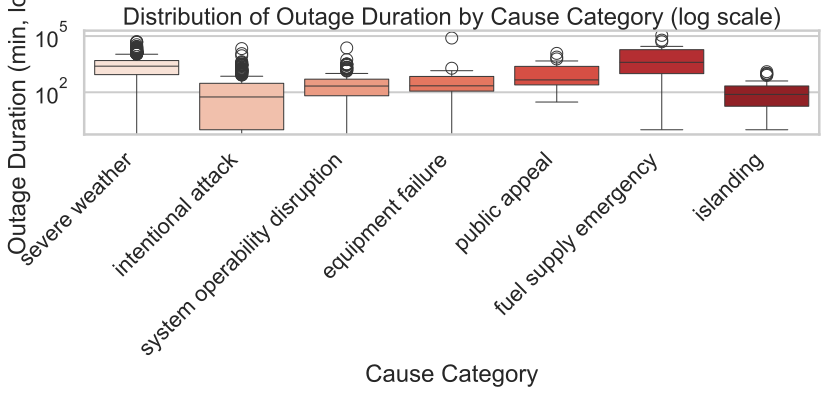

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(data=outage, x='CAUSE.CATEGORY', y='OUTAGE.DURATION', palette='Reds')
plt.yscale('log')  # logarithmic scale
plt.xticks(rotation=45, ha='right')
plt.ylabel('Outage Duration (min, log scale)')
plt.xlabel('Cause Category')
plt.title('Distribution of Outage Duration by Cause Category (log scale)')
plt.tight_layout()
plt.show()

We are seeing that is all the power outages per cause category and how the data is distributed. We see that there is quite a difference in distribution for each category. We use a log scale to better see the data.

## 5. Outage Duration by Climate Category

/var/folders/jq/nr60jgd12v1d3kf0gmn9fv_w0000gn/T/ipykernel_2656/2131113779.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




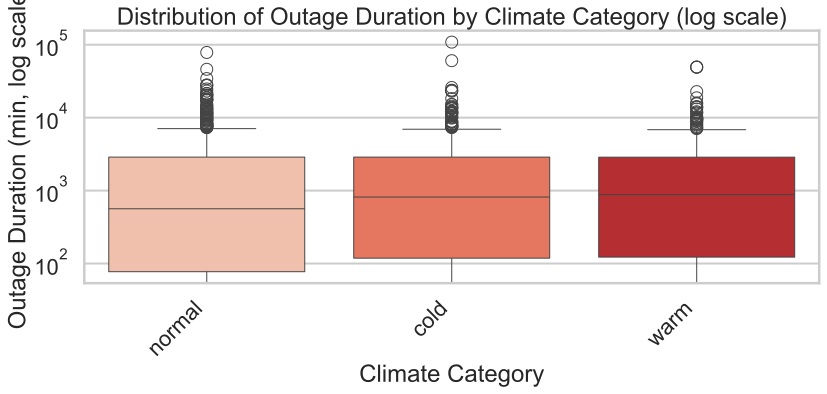

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(data=outage, x='CLIMATE.CATEGORY', y='OUTAGE.DURATION', palette='Reds')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Outage Duration (min, log scale)')
plt.xlabel('Climate Category')
plt.title('Distribution of Outage Duration by Climate Category (log scale)')
plt.tight_layout()
#plt.savefig('plots/outage_by_climate.png', bbox_inches='tight', dpi=150) 
plt.show()

We see how the power outages are distributed for the CLimate Category. We see that it is pretty similar for each category. 

## Aggregate Data

In [271]:
#aggregate the data by the CLIMATE.REGION column, find the average duration, max duration, total number of outages, and average number of customers affected for each region
agg_by_cause = outage.groupby('CLIMATE.REGION').agg(
    avg_duration=('OUTAGE.DURATION', 'mean'),
    max_duration=('OUTAGE.DURATION', 'max'),
    total_outages=('OUTAGE.DURATION', 'count'),
    avg_customers_affectd = ('CUSTOMERS.AFFECTED', 'mean')
).reset_index()
agg_by_cause

,CLIMATE.REGION,avg_duration,max_duration,total_outages,avg_customers_affectd
0,Central,2701.13,23773.0,191,131148.80
1,East North Central,5352.04,108653.0,137,138388.93
2,Hawaii,845.40,1906.0,5,147237.20
...,...,...,...,...,...
7,Southwest,1566.14,49320.0,88,40844.21
8,West,1628.33,49427.0,205,188540.76
9,West North Central,696.56,9600.0,16,47316.00


In [319]:
#examine the data
agg_by_cause.sort_values('max_duration', ascending=False)

,CLIMATE.REGION,avg_duration,max_duration,total_outages,avg_customers_affectd
1,East North Central,5352.04,108653.0,137,138388.93
3,Northeast,2991.66,60480.0,344,122144.77
8,West,1628.33,49427.0,205,188540.76
...,...,...,...,...,...
4,Northwest,1284.50,22769.0,122,74600.73
9,West North Central,696.56,9600.0,16,47316.00
2,Hawaii,845.40,1906.0,5,147237.20


We see how the outage duration is distrubted for the difference climate regions. We see that it is quite different for each region.

In [320]:
pivot = outage.pivot_table(
    index='CLIMATE.REGION',
    columns='CAUSE.CATEGORY',
    values='OUTAGE.DURATION',
    aggfunc='mean'
).round(0)

pivot

CAUSE.CATEGORY,equipment failure,fuel supply emergency,intentional attack,islanding,public appeal,severe weather,system operability disruption
CLIMATE.REGION,,,,,,,
Central,322.0,10035.0,346.0,125.0,1410.0,3250.0,2695.0
East North Central,26435.0,33971.0,2376.0,1.0,733.0,4435.0,2610.0
Hawaii,NaN,NaN,NaN,NaN,NaN,998.0,237.0
...,...,...,...,...,...,...,...
Southwest,114.0,76.0,266.0,2.0,2275.0,11573.0,329.0
West,525.0,6155.0,858.0,215.0,2028.0,2928.0,364.0
West North Central,61.0,NaN,24.0,68.0,440.0,2442.0,NaN


This shows average outage duration for every combination of climate region and cause category.

## Step 3: Assessment of Missingness

In [321]:
# TODO
outage['CUSTOMERS.AFFECTED'].isna().sum()/outage.shape[0]
outage['CA_missing'] = outage['CUSTOMERS.AFFECTED'].isna()
#around 30 percent of the data is missing for this column

Null Hypothesis: The missigness of the CUSTOMERS.AFFECTED column does not depend on the TOTAL.PRICE column.

Alternate Hypothesis. The missigness of the CUSTOMERS.AFFECTED column does depend on the TOTAL.PRICE column. 

In [322]:
# complete a permutation test for missingnes of customers affected column to see if it is dependent on the total price column
np.random.seed(42)
observed = (
    outage.groupby('CA_missing')['TOTAL.PRICE']
    .mean()
    .diff()
    .iloc[-1]
)
diffs = []

for i in range(5000):
    shuffled = outage['CA_missing'].sample(frac=1, replace=False).reset_index(drop=True)

    temp = outage.copy()
    temp['shuffled'] = shuffled

    stat = (
        temp.groupby('shuffled')['TOTAL.PRICE']
        .mean()
        .diff()
        .iloc[-1]
    )

    diffs.append(stat)

diffs = np.array(diffs)

p_value = np.mean(np.abs(diffs) >= abs(observed))
p_value

0.8248

The p-value is 0.8248 which is greater than 0.05 so we fail to reject the null hypothesis. The missingness in the CUSTOMERS.AFFECTED column does not have to do with the TOTAL.PRICE column.

Null Hypothesis: The missigness of the CUSTOMERS.AFFECTED column does not depend on the OUTAGE.DURATION column.

Alternate Hypothesis. The missigness of the CUSTOMERS.AFFECTED column does depend on the OUTAGE.DURATION column. 

In [324]:
# complete a permutation test for missingnes of customers affected column to see if it is dependent on the outage duration column
np.random.seed(42)
observed = (
    outage.groupby('CA_missing')['OUTAGE.DURATION']
    .mean()
    .diff()
    .iloc[-1]
)
diffs = []

for i in range(5000):
    shuffled = outage['CA_missing'].sample(frac=1, replace=False).reset_index(drop=True)

    temp = outage.copy()
    temp['shuffled'] = shuffled

    stat = (
        temp.groupby('shuffled')['OUTAGE.DURATION']
        .mean()
        .diff()
        .iloc[-1]
    )

    diffs.append(stat)

diffs = np.array(diffs)

p_value = np.mean(np.abs(diffs) >= abs(observed))
p_value

0.0282

The p-value is 0.0282 which is < 0.05 so we reject the null hypothesis. This is suggests the data is missing due to MAR.

Null Hypothesis: The missingness of the CUSTOMERS.AFFECTED column is the same across the categories of CAUSE.CATEGORY  
Alternate Hypothesis: This missingness of thh CUSTOMERS.AFFECTED column is dependent of the CAUSE.CATEGORY

In [ ]:
fig = px.histogram(
    x=diffs,
    nbins=50,
    title='Empirical Distribution of Mean Difference in Outage Duration<br>Under Null Hypothesis (Missingness of Customers Affected)',
    labels={'x': 'Mean Difference in Outage Duration (minutes)'},
    opacity=0.75
)

# add vertical line for observed statistic
fig.add_vline(
    x=observed,
    line_color='red',
    line_dash='dash',
    line_width=2,
    annotation_text=f'Observed: {observed:.2f}',
    annotation_position='top right',
    annotation_font_color='red'
)

fig.update_layout(
    yaxis_title='Count',
    showlegend=False
)

fig.show()
#fig.write_html('plots/missingness_permutation.html')

In [245]:
missing_table = pd.crosstab(outage['CAUSE.CATEGORY'], outage['CA_missing'])
missing_table

CA_missing,False,True
CAUSE.CATEGORY,,
equipment failure,26,29
fuel supply emergency,5,33
intentional attack,191,212
islanding,34,10
public appeal,21,48
severe weather,698,46
system operability disruption,81,42


In [247]:
# do a chi square test to see if the missingness of customers affected column is dependent on the cause category column
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(missing_table)

print("Chi-square statistic:", chi2)
print("p-value:", p)

Chi-square statistic: 436.23470905018536
p-value: 4.499550432701558e-91


The p-value is less than 0.05 meaning the data is most likely MAR and depends on the Cause Category.

## Step 4: Hypothesis Testing

Null Hypothesis: Power outages occurs at the same frequencies throughout the day.  
Alternate Hypothesis: Power outages occurs at different frequencies throughout the day.  
Test Statistic: Difference between the maximum and minimum proportion of 
outages across the two time periods (day vs. night)  
Significance Level = 0.05

In [330]:
# complete a hypothesis test to see if the time of day the outage started is uniformly distributed across the day, or if there are more outages during the day than at night, or vice versanp.random.seed(42)
def time_period(hour):
    if 0 <= hour < 6:
        return 'night'
    elif 6 <= hour < 18:
        return 'day'
    else:
        return 'night'
    
outage['time_period'] = outage['START.HOURS'].apply(time_period)
counts = outage['time_period'].value_counts(normalize=True)
observed = counts.max() - counts.min()

stats = []

for i in range(10000):
    # simulate under null: day/night equally likely (uniform = 50/50)
    simulated = np.random.choice(['day', 'night'], p=[0.5, 0.5], size=len(outage))
    counts = pd.Series(simulated).value_counts(normalize=True)
    stat = counts.max() - counts.min()
    stats.append(stat)

stats = np.array(stats)
p_value = np.mean(stats >= observed)
print(f"Observed: {observed:.4f}")
print(f"P-value: {p_value:.10f}")

Observed: 0.3008
P-value: 0.0000000000


The p-value is 0.00 which is less than 0.05 means that we reject the null hypothesis. The time of day outages start is not uniformly distributed across the day. 

In [ ]:
fig = px.histogram(
    x=stats,
    nbins=50,
    title='Empirical Distribution of Day/Night Proportion Difference<br>Under Null Hypothesis (Uniform Distribution)',
    labels={'x': 'Max - Min Proportion (Day vs Night)'},
    opacity=0.75
)

fig.add_vline(
    x=observed,
    line_color='red',
    line_dash='dash',
    line_width=2,
    annotation_text=f'Observed: {observed:.4f}',
    annotation_position='top left',
    annotation_font_color='red'
)

fig.update_layout(yaxis_title='Count')
fig.show()
#fig.write_html('plots/hypothesis_test.html')

## Step 5: Framing a Prediction Problem

Predict the duration of a power outage using features known at the time the outage begins.

## Step 6: Baseline Model

In [249]:
# TODO
# import things needed for the model
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import median_absolute_error

In [250]:
#create model to predict outage duration based on cause category, climate region, and time period of the day the outage started
#use a One Hot Encoder for the categorical variables and a linear regression model, evaluate using root mean squared error and median absolute error
X = outage[['CAUSE.CATEGORY','CLIMATE.REGION','time_period']]
y = outage['OUTAGE.DURATION']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
col_trans = make_column_transformer(
    (OneHotEncoder(drop='first'), ['CAUSE.CATEGORY','CLIMATE.REGION','time_period']),
    remainder='passthrough')
pl = make_pipeline(col_trans, LinearRegression())
pl.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(drop='first'),
                                                  ['CAUSE.CATEGORY',
                                                   'CLIMATE.REGION',
                                                   'time_period'])])),
                ('linearregression', LinearRegression())])

In [251]:
# see the results of the model
pred_train = pl.predict(X_train)
pred_test = pl.predict(X_test)
rmse_train_base = root_mean_squared_error(y_train, pred_train)
rmse_test_base = root_mean_squared_error(y_test, pred_test)
mae_test_base = median_absolute_error(y_test, pred_test)
mae_train_base = median_absolute_error(y_train, pred_train)
print(rmse_train_base)
print(rmse_test_base)
print(mae_train_base)
print(mae_test_base)

5728.072699080474
3745.411263395247
1294.4567015199605
1313.379653789379


Due the how the power outage duration is skewed, the median absolute error is a better predictor for our model than the root square mean error which is affected by the outliers.

## Step 7: Final Model

In [252]:
#explore the distribution of the outage duration column and how much it is affected by outliers
print(outage['OUTAGE.DURATION'].describe())
print(outage['OUTAGE.DURATION'].median())

count      1476.00
mean       2625.40
std        5942.48
           ...    
50%         701.00
75%        2880.00
max      108653.00
Name: OUTAGE.DURATION, Length: 8, dtype: float64
701.0


Decide due to the outliers to use mean absolute error going forward

In [265]:
# TODO
"""
Create the final model
Feature Engineering: Create a new column that is combination of CAUSE.CATEGORY and CLIMATE.CATEGORY, to see if the weather would affect how the cause of the outage impact the duration
Added columns: added the anomaly level column and day of week column to better predict the duration
applied a TransformedTargetRegressor so it helps accounts for the skew of the data
"""
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline


outage['CAUSE.CLIMATE'] = (outage['CAUSE.CATEGORY'].astype(str) + '_' + outage['CLIMATE.CATEGORY'].astype(str))
X_final = outage[['CLIMATE.REGION', 'time_period','CAUSE.CLIMATE', 'ANOMALY.LEVEL', 'DAY.OF.WEEK']]
y_final = outage['OUTAGE.DURATION']
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X_final, y_final, test_size=0.2)

col_trans_final = make_column_transformer(
    (OneHotEncoder(drop='first', handle_unknown='ignore'),
     ['CLIMATE.REGION', 'CAUSE.CLIMATE', 'time_period']),
    (StandardScaler(), ['ANOMALY.LEVEL']),
    remainder='drop'
)

pl_final = make_pipeline(
    col_trans_final,
    RandomForestRegressor(random_state=42)
)
tt_model = TransformedTargetRegressor(
    regressor=pl_final,
    func=np.log1p,
    inverse_func=np.expm1
)

param_grid = {
    'regressor__randomforestregressor__n_estimators': [100, 200, 300],
    'regressor__randomforestregressor__max_depth':    [5, 10, 20, 30],
    'regressor__randomforestregressor__min_samples_leaf': [10, 20, 50]
}

grid_search = GridSearchCV(
     tt_model,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_final, y_train_final)

best_pl = grid_search.best_estimator_

train_mae = median_absolute_error(y_train_final, best_pl.predict(X_train_final))
test_mae  = median_absolute_error(y_test_final,  best_pl.predict(X_test_final))

Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [266]:
train_mae

547.0788173669821

In [267]:
test_mae

491.6832607624495

The mean absolute error has improved a lot compared the the baseline.

## Step 8: Fairness Analysis

In [268]:
#do the fairness analysis on the NERC.REGION column, see what regions there are
print(outage['NERC.REGION'].value_counts().sort_values(ascending = False))

NERC.REGION
WECC          424
RFC           416
SERC          194
             ... 
FRCC, SERC      1
HI              1
PR              1
Name: count, Length: 13, dtype: int64


In [269]:
#seperate the regions in the eastern and western regions
eastern = ['RFC', 'SERC', 'NPCC', 'MRO', 'FRCC', 'SPP', 'TRE']
western = ['WECC']

def assign_group(region):
    if region in western:
        return 'western'
    elif region in eastern:
        return 'eastern'
    else:
        return 'other'

test_df = X_test_final.copy()
test_df['OUTAGE.DURATION'] = y_test_final.values
test_df['PREDICTED'] = best_pl.predict(X_test_final)
test_df['GROUP'] = outage.loc[X_test_final.index, 'NERC.REGION'].apply(assign_group)

test_df = test_df[test_df['GROUP'] != 'other']
print(test_df['GROUP'].value_counts())

GROUP
eastern    197
western     92
Name: count, dtype: int64


1. Groups  
Group X: Eastern interconnection (RFC, SERC, NPCC, MRO, FRCC, SPP, TRE) — 198 samples
Group Y: Western interconnection (WECC) — 89 samples

2. Metric: RMSE (since this is a regression model)
3. Hypotheses  
Null: The model is fair. Any RMSE difference between eastern and western regions is due to random chance
Alternative: The model is unfair. It performs differently for eastern vs western grid regions

4. Conclusion — depends on your p-value:  
p < 0.05 → reject null, evidence of unfairness
p >= 0.05 → fail to reject null, no significant difference detected

In [270]:
# do a permutation test to see if there is a significant difference in the median absolute error between the eastern and western regions, use the group_mae_diff function to calculate the difference in median absolute error between the two groups
def group_mae_diff(df):
    e = median_absolute_error(
        df[df['GROUP'] == 'eastern']['OUTAGE.DURATION'],
        df[df['GROUP'] == 'eastern']['PREDICTED']
    )
    w = median_absolute_error(
        df[df['GROUP'] == 'western']['OUTAGE.DURATION'],
        df[df['GROUP'] == 'western']['PREDICTED']
    )
    return e - w

observed_diff = group_mae_diff(test_df)
print(f"Observed MAE difference (eastern - western): {observed_diff:.2f}")

# Step 2 - permutation test
n_permutations = 1000
perm_diffs = []

for _ in range(n_permutations):
    shuffled = test_df.copy()
    shuffled['GROUP'] = np.random.permutation(shuffled['GROUP'].values)
    perm_diffs.append(group_mae_diff(shuffled))

perm_diffs = np.array(perm_diffs)

# Step 3 - p-value (two-sided)
p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print(f"P-value: {p_value:.4f}")

Observed MAE difference (eastern - western): 552.63
P-value: 0.0020


Since our p-value is less than our alpha of 0.05, it means that we reject the null hypothesis. There is a differenc ein prediction between the eastern and western power regions of the United States.